In [88]:
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sm
import sympy.physics.mechanics as me

me.init_vprinting(use_latex='mathjax')

psi, x, y = me.dynamicsymbols('\\psi x y')
q1, q2, q3 = me.dynamicsymbols('q_1 q_2 q_3')
upsi, ux, uy, u1, u2, u3 = me.dynamicsymbols('u_{\\psi} u_x u_y u_1, u_2, u_3')
d0, d1, d2, d3 = sm.symbols('d_0 d_1 d_2 d_3')
x0, y0 = sm.symbols('x_0 y_0')
r1, r2 = sm.symbols('r_1 r_2')
m1, m2, I1, I2 = sm.symbols('m_1 m_2 I_1 I_2')
k1, k2 = sm.symbols('k_1 k_2')
c1, c2 = sm.symbols('c_1 c_2')
theta1F, theta2F = sm.symbols('\\theta_{1F} \\theta_{2F}')
I0, m0 = sm.symbols('I_0, m_0')

t = me.dynamicsymbols._t

p = sm.Matrix([x0, y0, d0, d1, d2, d3, r1, r2, m0, m1, m2, I0, I1, I2, theta1F, theta2F, k1, k2, c1, c2])

q = sm.Matrix([psi, x, y, q1])
qr = sm.Matrix([q2, q3])
qN = q.col_join(qr)

u = sm.Matrix([upsi, ux, uy, u1])
ur = sm.Matrix([u2, u3])
uN = u.col_join(ur)

qdN = qN.diff(t)
ud = u.diff(t)

p, q, qr, qN, u, ur, uN, qdN, ud

⎛⎡    x₀     ⎤                                                                
⎜⎢           ⎥                                                                
⎜⎢    y₀     ⎥                                                                
⎜⎢           ⎥                                                                
⎜⎢    d₀     ⎥                                                                
⎜⎢           ⎥                                                                
⎜⎢    d₁     ⎥                                                                
⎜⎢           ⎥                                                                
⎜⎢    d₂     ⎥                                                                
⎜⎢           ⎥                                                                
⎜⎢    d₃     ⎥                                                                
⎜⎢           ⎥                                                                
⎜⎢    r₁     ⎥                                      

In [2]:
ur_zero = {ui: 0 for ui in ur}
uN_zero = {ui: 0 for ui in uN}
qdN_zero = {qdi: 0 for qdi in qdN}
ud_zero = {udi: 0 for udi in ud}

In [92]:
RN = me.ReferenceFrame('R_N')
R0 = me.ReferenceFrame('R_0')
R1 = me.ReferenceFrame('R_1')
R2 = me.ReferenceFrame('R_2')
R3 = me.ReferenceFrame('R_3')

R0.orient_axis(RN, psi, RN.z)
R1.orient_axis(R0, q1, R0.z)
R2.orient_axis(R1, q2, R1.z)
R3.orient_axis(R2, q3, R2.z)

O = me.Point('O')
CM0 = me.Point('CM_{0}')
CM1 = me.Point('CM_{1}')
CM2 = me.Point('CM_{2}')
A = me.Point('A')
B = me.Point('B')
C = me.Point('C')
D = me.Point('D')

In [93]:
O.set_vel(RN, 0)

CM0.set_pos(O, x*RN.x + y*RN.y)
D.set_pos(CM0, x0*R0.x + y0*R0.y)
C.set_pos(D, d1*R1.x)
B.set_pos(C, d2*R2.x)
A.set_pos(B, d3*R3.x)

CM1.set_pos(D, r1*R1.x)
CM2.set_pos(C, r2*R2.x)

A.pos_from(D)

d₃ r_3_x + d₂ r_2_x + d₁ r_1_x

In [94]:
r_D_A = -d0*R0.x
loop = A.pos_from(D) - r_D_A
loop

d₃ r_3_x + d₂ r_2_x + d₁ r_1_x + d₀ r_0_x

In [95]:
fhx = sm.trigsimp(loop.dot(R0.x))
fhx

d₀ + d₁⋅cos(q₁) + d₂⋅cos(q₁ + q₂) + d₃⋅cos(q₁ + q₂ + q₃)

In [96]:
fhy = sm.trigsimp(loop.dot(R0.y))
fhy

d₁⋅sin(q₁) + d₂⋅sin(q₁ + q₂) + d₃⋅sin(q₁ + q₂ + q₃)

In [97]:
fh = sm.Matrix([fhx, fhy])
fh

⎡d₀ + d₁⋅cos(q₁) + d₂⋅cos(q₁ + q₂) + d₃⋅cos(q₁ + q₂ + q₃)⎤
⎢                                                        ⎥
⎣  d₁⋅sin(q₁) + d₂⋅sin(q₁ + q₂) + d₃⋅sin(q₁ + q₂ + q₃)   ⎦

In [98]:
me.find_dynamicsymbols(fh)

{q₁, q₂, q₃}

In [99]:
fk = sm.Matrix([
    psi.diff(t) - upsi,
    x.diff(t) - ux,
    y.diff(t) - uy,
    q1.diff(t) - u1,
    q2.diff(t) - u2,
    q3.diff(t) - u3,
])
Mk = fk.jacobian(qdN)
gk = fk.xreplace(qdN_zero)
qdN_sol = -Mk.LUsolve(gk)
qd_repl = dict(zip(qdN, qdN_sol))
qd_repl

{\pṡi: u_{\psi}, q₁̇: u₁, q₂̇: u₂, q₃̇: u₃, ẋ: uₓ, ẏ: u_y}

In [100]:
Mk, gk

⎛⎡1  0  0  0  0  0⎤  ⎡-u_{\psi}⎤⎞
⎜⎢                ⎥  ⎢         ⎥⎟
⎜⎢0  1  0  0  0  0⎥  ⎢   -uₓ   ⎥⎟
⎜⎢                ⎥  ⎢         ⎥⎟
⎜⎢0  0  1  0  0  0⎥  ⎢  -u_y   ⎥⎟
⎜⎢                ⎥, ⎢         ⎥⎟
⎜⎢0  0  0  1  0  0⎥  ⎢   -u₁   ⎥⎟
⎜⎢                ⎥  ⎢         ⎥⎟
⎜⎢0  0  0  0  1  0⎥  ⎢   -u₂   ⎥⎟
⎜⎢                ⎥  ⎢         ⎥⎟
⎝⎣0  0  0  0  0  1⎦  ⎣   -u₃   ⎦⎠

In [101]:
t = me.dynamicsymbols._t
fhd = fh.diff(t).xreplace(qd_repl)
fhd

⎡-d₁⋅u₁⋅sin(q₁) - d₂⋅(u₁ + u₂)⋅sin(q₁ + q₂) - d₃⋅(u₁ + u₂ + u₃)⋅sin(q₁ + q₂ + 
⎢                                                                             
⎣d₁⋅u₁⋅cos(q₁) + d₂⋅(u₁ + u₂)⋅cos(q₁ + q₂) + d₃⋅(u₁ + u₂ + u₃)⋅cos(q₁ + q₂ + q

q₃)⎤
   ⎥
₃) ⎦

In [102]:
me.find_dynamicsymbols(fhd)

{q₁, q₂, q₃, u₁, u₂, u₃}

In [103]:
Mhd = fhd.jacobian(ur)
ghd = fhd.xreplace(ur_zero)
ur_sol = sm.trigsimp(-Mhd.LUsolve(ghd))
ur_repl = dict(zip(ur, ur_sol))

In [104]:
ur_repl[u2]

                 d₁⋅(d₂⋅sin(q₂) + d₃⋅sin(q₂ + q₃))⋅u₁⋅sin(q₁ + q₂ + q₃)       
-d₁⋅u₁⋅sin(q₁) - ────────────────────────────────────────────────────── - d₂⋅u
                                       d₂⋅sin(q₃)                             
──────────────────────────────────────────────────────────────────────────────
                                        d₂⋅sin(q₁ + q₂) + d₃⋅sin(q₁ + q₂ + q₃)

                                        
₁⋅sin(q₁ + q₂) - d₃⋅u₁⋅sin(q₁ + q₂ + q₃)
                                        
────────────────────────────────────────
                                        

In [105]:
ur_repl[u3]

d₁⋅(d₂⋅sin(q₂) + d₃⋅sin(q₂ + q₃))⋅u₁
────────────────────────────────────
           d₂⋅d₃⋅sin(q₃)            

In [106]:
gk = gk.xreplace(ur_repl)
gk

⎡                                                        -u_{\psi}            
⎢                                                                             
⎢                                                           -uₓ               
⎢                                                                             
⎢                                                           -u_y              
⎢                                                                             
⎢                                                           -u₁               
⎢                                                                             
⎢ ⎛                 d₁⋅(d₂⋅sin(q₂) + d₃⋅sin(q₂ + q₃))⋅u₁⋅sin(q₁ + q₂ + q₃)    
⎢-⎜-d₁⋅u₁⋅sin(q₁) - ────────────────────────────────────────────────────── - d
⎢ ⎝                                       d₂⋅sin(q₃)                          
⎢─────────────────────────────────────────────────────────────────────────────
⎢                                          d₂⋅sin(q₁

In [107]:
R0.set_ang_vel(RN, upsi*RN.z)
R1.set_ang_vel(R0, u1*R0.z)
R2.set_ang_vel(R1, ur_repl[u2]*R1.z)
R3.set_ang_vel(R2, ur_repl[u3]*R2.z)

(me.find_dynamicsymbols(R0.ang_vel_in(RN), reference_frame=RN) |
 me.find_dynamicsymbols(R1.ang_vel_in(RN), reference_frame=RN) |
 me.find_dynamicsymbols(R2.ang_vel_in(RN), reference_frame=RN) |
 me.find_dynamicsymbols(R3.ang_vel_in(RN), reference_frame=RN))

{q₁, q₂, q₃, u₁, u_{\psi}}

In [108]:
CM0.set_vel(RN, ux*RN.x + uy*RN.y)
D.v2pt_theory(CM0, RN, R0)
CM1.v2pt_theory(D, RN, R1)
C.v2pt_theory(D, RN, R1)
CM2.v2pt_theory(C, RN, R2)
B.v2pt_theory(C, RN, R2)
A.v2pt_theory(B, RN, R3)

(me.find_dynamicsymbols(CM0.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(D.vel(RN), reference_frame=RN)   |
 me.find_dynamicsymbols(CM1.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(C.vel(RN), reference_frame=RN)   |
 me.find_dynamicsymbols(CM2.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(B.vel(RN), reference_frame=RN)   |
 me.find_dynamicsymbols(A.vel(RN), reference_frame=RN))

{\psi, q₁, q₂, q₃, u₁, uₓ, u_y, u_{\psi}}

In [20]:
# Replacing variables
CM0.set_vel(RN, CM0.vel(RN).xreplace(qd_repl).xreplace(ur_repl))
D.set_vel(RN, D.vel(RN).xreplace(qd_repl).xreplace(ur_repl))
CM1.set_vel(RN, CM1.vel(RN).xreplace(qd_repl).xreplace(ur_repl))
C.set_vel(RN, C.vel(RN).xreplace(qd_repl).xreplace(ur_repl))
CM2.set_vel(RN, CM2.vel(RN).xreplace(qd_repl).xreplace(ur_repl))
B.set_vel(RN, B.vel(RN).xreplace(qd_repl).xreplace(ur_repl))
A.set_vel(RN, A.vel(RN).xreplace(qd_repl).xreplace(ur_repl))

(me.find_dynamicsymbols(CM0.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(D.vel(RN), reference_frame=RN)   |
 me.find_dynamicsymbols(CM1.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(C.vel(RN), reference_frame=RN)   |
 me.find_dynamicsymbols(CM2.vel(RN), reference_frame=RN) |
 me.find_dynamicsymbols(B.vel(RN), reference_frame=RN)   |
 me.find_dynamicsymbols(A.vel(RN), reference_frame=RN))

{\psi, q₁, q₂, q₃, u₁, uₓ, u_y, u_{\psi}}

In [109]:
CM0.vel(RN), D.vel(RN), CM1.vel(RN), C.vel(RN), CM2.vel(RN), B.vel(RN), A.vel(RN)

⎛uₓ r_n_x + u_y r_n_y, uₓ r_n_x + u_y r_n_y + -y₀⋅u_{\psi} r_0_x + x₀⋅u_{\psi}
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                                             
⎜                                                   

In [240]:
# Generalized active forces
TR0 = -k1*(theta1F - q1)*R0.z + c1*u1*R0.z
TR1 =  k1*(theta1F - q1)*R1.z + k2*(q2 - theta2F)*R1.z - c1*u1*R1.z + c2*ur_repl[u2]*R1.z
TR2 = -k2*(q2 - theta2F)*R2.z - c2*ur_repl[u2]*R2.z

FR0 = 0*RN.x + 0*RN.y + 0*RN.z
FR1 = 0*RN.x + 0*RN.y + 0*RN.z
FR2 = 0*RN.x + 0*RN.y + 0*RN.z


In [241]:
# Partial linear velocities
v_CM0_upsi = CM0.vel(RN).diff(upsi, RN)
v_CM0_ux   = CM0.vel(RN).diff(ux, RN)
v_CM0_uy   = CM0.vel(RN).diff(uy, RN)
v_CM0_u1   = CM0.vel(RN).diff(u1, RN)

v_CM1_upsi = CM1.vel(RN).diff(upsi, RN)
v_CM1_ux   = CM1.vel(RN).diff(ux, RN)
v_CM1_uy   = CM1.vel(RN).diff(uy, RN)
v_CM1_u1   = CM1.vel(RN).diff(u1, RN)

v_CM2_upsi = CM2.vel(RN).diff(upsi, RN)
v_CM2_ux   = CM2.vel(RN).diff(ux, RN)
v_CM2_uy   = CM2.vel(RN).diff(uy, RN)
v_CM2_u1   = CM2.vel(RN).diff(u1, RN)

v_CM0_upsi, v_CM0_ux, v_CM0_uy, v_CM0_u1


(0, r_n_x, r_n_y, 0)

In [242]:
# Partial angular velocities
w_R0_upsi = R0.ang_vel_in(RN).diff(upsi, RN)
w_R0_ux   = R0.ang_vel_in(RN).diff(ux, RN)
w_R0_uy   = R0.ang_vel_in(RN).diff(uy, RN)
w_R0_u1   = R0.ang_vel_in(RN).diff(u1, RN)

w_R1_upsi = R1.ang_vel_in(RN).diff(upsi, RN)
w_R1_ux  = R1.ang_vel_in(RN).diff(ux, RN)
w_R1_uy  = R1.ang_vel_in(RN).diff(uy, RN)
w_R1_u1  = R1.ang_vel_in(RN).diff(u1, RN)

w_R2_upsi = R2.ang_vel_in(RN).diff(upsi, RN)
w_R2_ux  = R2.ang_vel_in(RN).diff(ux, RN)
w_R2_uy  = R2.ang_vel_in(RN).diff(uy, RN)
w_R2_u1  = R2.ang_vel_in(RN).diff(u1, RN)

In [243]:
Fr = sm.Matrix([
    v_CM0_upsi.dot(FR0) + v_CM1_upsi.dot(FR1) + v_CM2_upsi.dot(FR2) + w_R0_upsi.dot(TR0) + w_R1_upsi.dot(TR1) + w_R2_upsi.dot(TR2),
    v_CM0_ux.dot(FR0) + v_CM1_ux.dot(FR1) + v_CM2_ux.dot(FR2) + w_R0_ux.dot(TR0) + w_R1_ux.dot(TR1) + w_R2_ux.dot(TR2),
    v_CM0_uy.dot(FR0) + v_CM1_uy.dot(FR1) + v_CM2_uy.dot(FR2) + w_R0_uy.dot(TR0) + w_R1_uy.dot(TR1) + w_R2_uy.dot(TR2),
    v_CM0_u1.dot(FR0) + v_CM1_u1.dot(FR1) + v_CM2_u1.dot(FR2) + w_R0_u1.dot(TR0) + w_R1_u1.dot(TR1) + w_R2_u1.dot(TR2),
])

In [244]:
me.find_dynamicsymbols(Fr)

{q₁, q₂, q₃, u₁}

In [245]:
me.find_dynamicsymbols(CM0.acc(RN), reference_frame=RN) 

{uₓ, u_y, uₓ̇, u_̇y}

In [246]:
me.find_dynamicsymbols(CM1.acc(RN), reference_frame=RN)

{\psi, q₁, u₁, uₓ, u_y, u_{\psi}, u₁̇, uₓ̇, u_̇y, u_{\ṗsi}}

In [247]:
me.find_dynamicsymbols(CM2.acc(RN), reference_frame=RN)

{\psi, q₁, q₂, q₃, u₁, uₓ, u_y, u_{\psi}, q₁̇, q₂̇, q₃̇, u₁̇, uₓ̇, u_̇y, u_{\ṗsi}}

In [248]:
me.find_dynamicsymbols(R0.ang_acc_in(RN), reference_frame=RN)

{u_{\psi}, u_{\ṗsi}}

In [249]:
me.find_dynamicsymbols(R1.ang_acc_in(RN), reference_frame=RN)

{u₁, u_{\psi}, u₁̇, u_{\ṗsi}}

In [250]:
me.find_dynamicsymbols(R2.ang_acc_in(RN), reference_frame=RN)

{q₁, q₂, q₃, u₁, u_{\psi}, q₁̇, q₂̇, q₃̇, u₁̇, u_{\ṗsi}}

In [251]:
Rs_CM0 = -m0*CM0.acc(RN)
Rs_CM1 = -m1*CM1.acc(RN)
Rs_CM2 = -m2*CM2.acc(RN).xreplace(qd_repl).xreplace(ur_repl)

# Rod inertias
inertia0 = I0*me.outer(R0.z, R0.z)
inertia1 = I1*me.outer(R1.z, R1.z)
inertia2 = I2*me.outer(R2.z, R2.z)

Ts0 = -(R0.ang_acc_in(RN).dot(inertia0) + me.cross(R0.ang_vel_in(RN), inertia0).dot(R0.ang_vel_in(RN)))
Ts1 = -(R1.ang_acc_in(RN).dot(inertia1) + me.cross(R1.ang_vel_in(RN), inertia1).dot(R1.ang_vel_in(RN)))
Ts2 = -(R2.ang_acc_in(RN)).xreplace(qd_repl).xreplace(ur_repl).dot(inertia2) + me.cross(R2.ang_vel_in(RN), inertia2).dot(R2.ang_vel_in(RN))

Frs = sm.Matrix([
    v_CM0_upsi.dot(Rs_CM0) + v_CM1_upsi.dot(Rs_CM1) + v_CM2_upsi.dot(Rs_CM2) + w_R0_upsi.dot(Ts0) + w_R1_upsi.dot(Ts1) + w_R2_upsi.dot(Ts2),
    v_CM0_ux.dot(Rs_CM0) + v_CM1_ux.dot(Rs_CM1) + v_CM2_ux.dot(Rs_CM2) + w_R0_ux.dot(Ts0) + w_R1_ux.dot(Ts1) + w_R2_ux.dot(Ts2),
    v_CM0_uy.dot(Rs_CM0) + v_CM1_uy.dot(Rs_CM1) + v_CM2_uy.dot(Rs_CM2) + w_R0_uy.dot(Ts0) + w_R1_uy.dot(Ts1) + w_R2_uy.dot(Ts2),
    v_CM0_u1.dot(Rs_CM0) + v_CM1_u1.dot(Rs_CM1) + v_CM2_u1.dot(Rs_CM2) + w_R0_u1.dot(Ts0) + w_R1_u1.dot(Ts1) + w_R2_u1.dot(Ts2),
])


In [252]:
# Equations of motion
Md = Frs.jacobian(ud)
gd = Frs.xreplace(ud_zero) + Fr

In [253]:
me.find_dynamicsymbols(Mk), me.find_dynamicsymbols(gk)

(set(), {q₁, q₂, q₃, u₁, uₓ, u_y, u_{\psi}})

In [254]:
me.find_dynamicsymbols(Md), me.find_dynamicsymbols(gd)

({\psi, q₁, q₂, q₃}, {\psi, q₁, q₂, q₃, u₁, u_{\psi}})

In [255]:
Mk.free_symbols | gk.free_symbols | Md.free_symbols | gd.free_symbols

{I₀, I₁, I₂, \theta_{1F}, \theta_{2F}, c₁, c₂, d₁, d₂, d₃, k₁, k₂, m₀, m₁, m₂,
 r₁, r₂, t, x₀, y₀}

In [256]:
eval_k = sm.lambdify((qN, u, p), (Mk, gk))
eval_d = sm.lambdify((qN, u, p), (Md, gd))

In [257]:
# q values just for try
q_vals = np.array([
    np.deg2rad(0.0),  # psi, rad
    0,                # x, m
    0,                # y, m
    np.deg2rad(10.0), # q1, rad
    np.deg2rad(10.0), # q2, rad
    np.deg2rad(10.0), # q3, rad
])
q_vals, type(q_vals), q_vals.shape

(array([0.        , 0.        , 0.        , 0.17453293, 0.17453293,
        0.17453293]),
 numpy.ndarray,
 (6,))

In [258]:
# u values just for try
u_vals = np.array([
    0,    # upsi, rad/s
    0,    # ux, m/s
    0,    # uy, m/s
    0.1,  # u1, rad/s
])
u_vals, type(u_vals), u_vals.shape

(array([0. , 0. , 0. , 0.1]), numpy.ndarray, (4,))

In [259]:
# Parameter values

p_vals = np.array([
    -0.2171, # x0, m
    0.7409,  # y0, m
    0.15225, # d0, m
    1.32588, # d1, m
    0.08024, # d2, m
    1.4165, # d3, m
    0.8915, # r1, m
    1.8288, # r2, m
    1150-8.889-36.891-0.2*1150, # Estimation of the main body mass (m0) forom INSAT 1-A Satellite (total mass, Yoke, Array and fuel)
    8.899, # m1, kg
    36.891, # m2, kg
    360.3, # I0, kgm^2
    0.9369, # I1, kgm^2
    43.527, # I2, kgm^2
    np.deg2rad(240.0), # theta1F, rad
    np.deg2rad(298.0), # theta2Fo, rad
    0.6114, # k1o, Nm/rad
    -0.776, # k2o, Nm/rad
    2*0.02*np.sqrt(1582.3*0.9369), # c1, Ns/m
    2*0.02*np.sqrt(28523.5*43.527), # c2, Ns/m
]) 
p_vals, type(p_vals), p_vals.shape
np.sqrt(28523.5*43.527)

1114.2452084258653

In [260]:
# Matrix values just for try
Mk_vals, gk_vals, = eval_k(q_vals, u_vals, p_vals)
Md_vals, gd_vals = eval_d(q_vals, u_vals, p_vals)
Mk_vals, gk_vals, Md_vals, gd_vals

(array([[1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1]]),
 array([[-0.        ],
        [-0.        ],
        [-0.        ],
        [-0.1       ],
        [ 3.35457852],
        [-3.34818106]]),
 array([[-8.00536465e+02,  6.68719219e+01, -1.09439410e+02,
          8.25160044e+03],
        [ 6.68719219e+01, -9.20010000e+02,  0.00000000e+00,
         -7.41116851e+02],
        [-1.09439410e+02,  0.00000000e+00, -9.20010000e+02,
          2.00734009e+03],
        [ 8.25160044e+03, -7.41116851e+02,  2.00734009e+03,
         -1.71133763e+05]]),
 array([[-16366.405664  ],
        [  2099.4167029 ],
        [ -3677.04932732],
        [325855.65504762]]))

In [261]:
def eval_rhs(t, x, p):
    """Return the derivative of the state at time t.
    Parameters
    ==========
    t : float
    x : array_like, shape(10,)
        x = [psi, x, y, q1, q2, q3, upsi, ux, uy, u1]
    p : array_like, shape(20,)
        p = [...]
    Returns
    =======
    xd : ndarray, shape(10,)
        xd = [psid, xd, yd, q1d, q2d, q3d, upsid, uxd, uyd, u1d]
    """
    
    qN = x[:6] # shape(6,)
    u = x[6:] # shape(4,)
    
    Mk, gk = eval_k(qN, u, p)
    qNd = -np.linalg.solve(Mk, np.squeeze(gk))
    
    Md, gd = eval_d(qN, u, p)
    ud = -np.linalg.solve(Md, np.squeeze(gd))
    
    return np.hstack((qNd, ud))

In [262]:
# If we needed to find the initial values from one joint value (q1). This is not our case

#from scipy.optimize import fsolve

#eval_fh = sm.lambdify((qr, q1, p), fh)

#q2_val, q3_val = fsolve(
#lambda qr, q1, p: np.squeeze(eval_fh(qr, q1, p)), # squeeze to a 1d array
#qr_guess, # initial guess for q2 and q3
#args=(q1_val, p_vals)) # known values in fh

In [263]:
from scipy.integrate import solve_ivp

# Initial generalized coordinates and generalized speeds
qN0 = [0.0, 0.0, 0.0, np.deg2rad(0.294),np.deg2rad(172.817), np.deg2rad(7.283)] 
uN0 = [0.0, 0.0, 0.0, 0.0]

# Initial time
t0 = 0.0 # s

# Final time
tf = 50.0 # s

# Time span
t_span = [t0, tf] 

# Initial conditions.
y0 = np.array(qN0 + uN0) 

# q2 update event
def event_q2(t,y,p):
    return y[4] - np.deg2rad(5.0) # q2 joint update
event_q2.terminal = True # Ends the integration
event_q2.direction = -1 # Detect values from positive to negative

# q2f update event
def event_q2lu(t,y,p):
    return y[4] - np.deg2rad(-3.0) # q2 joint update latch-up
event_q2lu.terminal = True # Ends the integration
event_q2lu.direction = -1 # Detect values from positive to negative

# q1f update event
def event_q1lu(t,y,p):
    return y[3] - np.deg2rad(90.0) # q1 joint update latch-up
event_q1lu.terminal = True # Ends the integration
event_q1lu.direction = 1 # Detect values from negative to positive

# List of index states for active events
active_events_index = [0, 1, 2]  # Corresponds to the indexes of states with events (q1f, q2, q2f)

# Simulation
total_time = []
total_states = []

initial_t = t_span[0]

while initial_t < t_span[1]:
    # Select active events
    events_act = []
    
    for idx in active_events_index:
        if idx == 0:
            events_act.append(event_q1lu)
        elif idx == 1:
            events_act.append(event_q2)
        elif idx == 2:
            events_act.append(event_q2lu)

    print(events_act)
    # Integrate the system with active events
    sol = solve_ivp(eval_rhs, [initial_t, t_span[1]], y0, args=(p_vals,), events=events_act, dense_output=True)
    
    # Save partial results
    total_time.append(sol.t)
    total_states.append(sol.y)
 
    print(sol.t_events)
    print(sol.y_events)
    
    # Check if any event occurred
    for i, t_event in enumerate(sol.t_events):
        if t_event.size > 0:  # If the event occurred
            t_event = t_event[0]
            y_event = sol.y_events[i][0]

            # Identify the index of the state corresponding to the event
            idx_state = active_events_index[i]
            print(idx_state)
            # Update stiffness depending on event
            if idx_state == 0:
                # Update stiffness of q1 
                p_vals[14] = np.pi/2
                p_vals[16] = 1582.3 # k1f
            elif idx_state == 1:
                # Update stiffness and the final angle 
                p_vals[15] = np.deg2rad(12.7) # thetaF2
                p_vals[17] = -40.1 # k2
            elif idx_state == 2:
                # Update stiffness of q2 
                p_vals[15] = np.deg2rad(-3.0)
                p_vals[17] = 28523.5 # k2f

            # Remove the status index from the active event list
            active_events_index.remove(idx_state)

            # Update the intial conditions
            y0 = sol.sol(t_event) + 1e-6
            initial_t = t_event  # Avoid re-integrating at the same point  
            
            break

    else:
        # If there were no events, finish the simulation
        break

# Combine results into single arrays
ts = np.concatenate(total_time)
ys = np.hstack(total_states)

[<function event_q1lu at 0x000001A27FBB0310>, <function event_q2 at 0x000001A27FD4E5E0>, <function event_q2lu at 0x000001A201A1E4C0>]
[array([], dtype=float64), array([35.0049206]), array([], dtype=float64)]
[array([], dtype=float64), array([[ 2.65260696e-01,  3.37840939e-02, -1.16763463e-01,
         1.52432807e+00,  8.72664626e-02,  2.93871563e+00,
         2.24864527e-02, -1.34736424e-03, -3.73641790e-04,
         8.33701523e-03]]), array([], dtype=float64)]
1
[<function event_q1lu at 0x000001A27FBB0310>, <function event_q2lu at 0x000001A201A1E4C0>]
[array([], dtype=float64), array([36.26264497])]
[array([], dtype=float64), array([[ 3.03402998e-01,  3.13021083e-02, -1.17003554e-01,
         1.53337195e+00, -5.23598776e-02,  3.07038236e+00,
         4.08249734e-02, -2.84938600e-03,  1.28336123e-04,
         4.77665057e-03]])]
2
[<function event_q1lu at 0x000001A27FBB0310>]
[array([], dtype=float64)]
[array([], dtype=float64)]


6.0

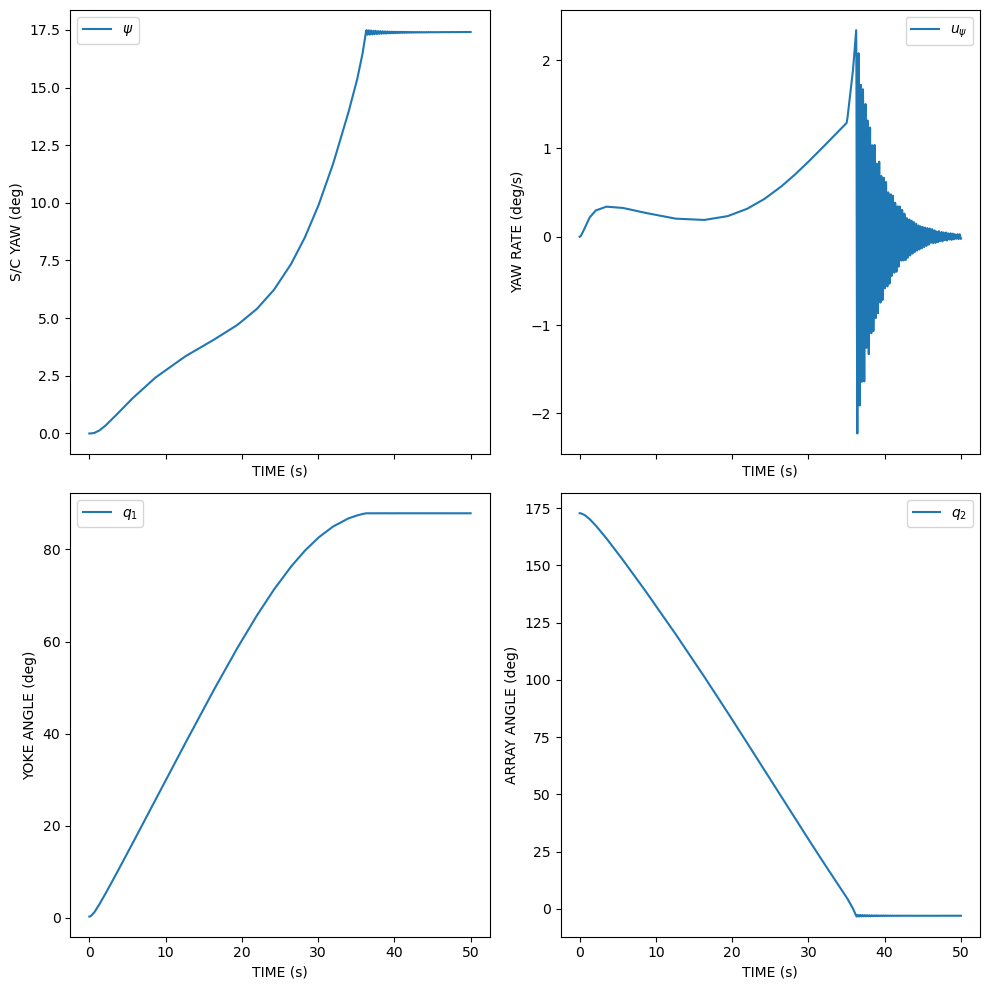

In [267]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, sharex=True)
fig.set_size_inches((10.0, 10.0))

axes[0,0].plot(ts, np.rad2deg(ys[0,:]))
axes[0,1].plot(ts, np.rad2deg(ys[6,:]))
axes[1,0].plot(ts, np.rad2deg(ys[3,:]))
axes[1,1].plot(ts, np.rad2deg(ys[4,:]))

axes[0,0].legend([me.vlatex(qN[0], mode='inline')])
axes[0,1].legend([me.vlatex(uN[0], mode='inline')])
axes[1,0].legend([me.vlatex(qN[3], mode='inline')])
axes[1,1].legend([me.vlatex(qN[4], mode='inline')])

axes[0,0].set_ylabel('S/C YAW (deg)')
axes[0,1].set_ylabel('YAW RATE (deg/s)')
axes[1,0].set_ylabel('YOKE ANGLE (deg)')
axes[1,1].set_ylabel('ARRAY ANGLE (deg)')

axes[0,0].set_xlabel('TIME (s)')
axes[0,1].set_xlabel('TIME (s)')
axes[1,0].set_xlabel('TIME (s)')
axes[1,1].set_xlabel('TIME (s)')

fig.tight_layout()

np.sqrt(36)